# **Exercício Duelo de Modelos 4**

Nesta tarefa, vocês irão criar o seu próprio duelo de modelos, com o objetivo de superar os resultados apresentados em aula. O desafio é alcançar um desempenho superior ao que obtivemos, e para isso, será necessário aplicar todas as melhorias que vocês aprenderam ao longo dos módulos, utilizando a base de dados do Titanic.

**1. Escolha do Modelo:**
Selecione um dos modelos que foram explorados nos duelos de modelos ao longo do curso. Pode ser SVM, Random Forest, XGBoost, ou qualquer outro que tenhamos abordado.

**2. Aperfeiçoamento:**
**Aplique as técnicas que aprendemos para melhorar o desempenho do seu modelo:**

**Hiperparâmetros:** Utilize GridSearchCV ou RandomSearchCV para encontrar os melhores parâmetros.

**Cross Validation:** Avalie a robustez do modelo utilizando validação cruzada para garantir que ele generaliza bem.

**Balanceamento de Classes:** Se o seu modelo lida com problemas de classes desbalanceadas, explore técnicas como SMOTE, undersampling ou oversampling.

**Padronização e Normalização:** Lembre-se de padronizar os dados, especialmente se for usar modelos que são sensíveis à escala das variáveis.

**3. Submissão no Kaggle:**
Treine o seu modelo com os dados de treino e gere as previsões para os dados de teste. Lembre-se de que o conjunto de teste não possui a variável alvo (y_test), pois a avaliação será feita com base nas submissões no Kaggle.
Submeta suas previsões na competição do Titanic no Kaggle.

**4. Entrega:**
Envie o código que você desenvolveu, detalhando cada etapa do seu processo de modelagem, explicando as escolhas feitas e como essas ajudaram a melhorar o modelo.

Junto com o código, envie um print do seu score obtido na plataforma do Kaggle. Esse score será a sua métrica final de avaliação, mostrando como o seu modelo se compara com os demais.

**5. Competição Saudável:**
A ideia é trazer um senso de competição saudável, então não vale replicar exatamente o que fizemos na aula! Inove, explore novas combinações de parâmetros e técnicas, e mostre do que é capaz. O importante é exercitar o pensamento crítico e a capacidade de experimentar.

**Dicas Finais:**

Seja criativo e tenha um olhar crítico sobre o que pode ser melhorado.
Teste diferentes abordagens e não se prenda a um único caminho.
Lembre-se de que, mais do que alcançar o melhor score, o objetivo é aprender e aplicar o conhecimento de forma prática e eficaz.
Boa sorte! Estamos ansiosos para ver como cada um de vocês vai se sair nesse desafio e quais insights irão surgir dessa competição!

Ao final dessa atividade vocês terão participado da primeira competição publica de ciência de dados de vocês = )




# Importações

In [31]:
# Importações para arquivos

import os

# Importações para dados

import numpy as np
import pandas as pd

# Importação de modelo para tratamento de dados
 
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Importações para gráficos

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Importações para pre-processamento

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Importações de modelo

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Importações par hiperparâmetros

from sklearn.model_selection import RandomizedSearchCV, cross_val_score

# Importações para métricas

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Data Dictionary — Titanic

| Variável | Definição | Valores |
|----------|-----------|---------|
| **Survived** | Sobrevivência (variável target) | 0 = Não sobreviveu, 1 = Sobreviveu |
| **Pclass** | Classe do bilhete | 1 = 1ª classe, 2 = 2ª classe, 3 = 3ª classe |
| **Sex** | Sexo do passageiro | male, female |
| **Age** | Idade em anos | Numérico  |
| **SibSp** | Nº de irmãos / cônjuges a bordo | Numérico |
| **Parch** | Nº de pais / filhos a bordo | Numérico |
| **Ticket** | Número do bilhete | Categórico |
| **Fare** | Tarifa paga pelo passageiro | Numérico |
| **Cabin** | Número da cabine | Categórico |
| **Embarked** | Porto de embarque | C = Cherbourg, Q = Queenstown, S = Southampton |



# Carregando base de dados

- Carregando base de dados

In [32]:
# Verificando se o arquivo foi encontrado

path = "./train.csv"
path2 = "./test.csv"

if os.path.exists(path):
    print("Arquivo de treino encontrado! ")
    if os.path.exists(path2):
        print("\nArquivo de teste encontrado! ")
    else:
        print("\nArquivo de teste não encontrado. ")
else:
    print("\nArquivo de treino não encontrado. ")

# Definindo df (Instanciando suas versões originais)

train_inicial = pd.read_csv(path)

test_inicial = pd.read_csv(path2)

# Instanciando versões que serão modificadas

train = train_inicial

test = test_inicial

Arquivo de treino encontrado! 

Arquivo de teste encontrado! 


- Verificando df treino

In [33]:
# Verificação Incial

train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


- Verificando teste 

In [34]:
# Guardando coluna PassengerID

pas_ID = test['PassengerId'].copy()

# Verificação inical

test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


Obs: Na verificação inicial, identificamos duas colunas que não vão contribuir para o modelo: PassengerId, que é apenas um identificador único sem valor preditivo, e Ticket, cujo número também não carrega informação relevante para prever sobrevivência. Ambas foram removidas tanto do conjunto de treino quanto do de teste. O PassengerId do conjunto de teste foi preservado em uma variável separada (pas_ID), já que será necessário no momento da submissão ao Kaggle.

# Feature Engineering e Tratamento de dados

- Verificação Inicial para tratamento de dados

In [35]:
# Verificando dados de treino

print("Dados de treino: ")
print(train.info())

Dados de treino: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [36]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [37]:
# Verificando dados de teste

print("Dados de teste: ")
print(test.info())

Dados de teste: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None


In [38]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Obs: A verificação inicial dos dados revela alguns pontos importantes a serem tratados antes da modelagem

Em relação às colunas categóricas:

A coluna Sex é categórica e precisará ser codificada para que o modelo consiga interpretá-la corretamente. <br>
A coluna Embarked também é categórica e precisará ser codificada para que o modelo consiga interpretá-la corretamente. <br>

Em relação aos valores nulos, temos três situações distintas:

Age apresenta 177 nulos no treino e 86 no teste — um volume considerável que não pode ser simplesmente ignorado, então trabalharemos para preenchê-los com valores que façam sentido. <br>
Cabin tem 687 nulos no treino (77% dos dados), o que torna inviável qualquer tentativa de preenchimento direto. A estratégia aqui será transformá-la via feature engineering em uma variável binária — CabinKnown — indicando se o passageiro tinha cabine registrada ou não, informação que por si só pode ser relevante para o modelo. <br>
Embarked possui apenas 2 nulos no treino, sendo bem simples de resolver. <br>
Fare possui apenas 1 valor nulo, sendo bem simples de resolver <br>

- Tratamento dos valores nulos simples

In [39]:
# Tratando valores nulos da coluna Fare

test['Fare'] = test['Fare'].fillna(test['Fare'].median()) # Trocando valor nulo pela mediana


In [40]:
# Tratando valores nulos de Embarked

mode_embarked = train['Embarked'].mode()[0]                     # Descobrindo a Moda (valor que mais aparece)
print(mode_embarked)
train['Embarked'] = train['Embarked'].fillna(mode_embarked)

S


In [41]:
# Tratando valores nulos de Cabin

train['Cabin_known'] = train['Cabin'].notna().astype(int)
test['Cabin_known'] = test['Cabin'].notna().astype(int)

# Removendo coluna Cabine

train = train.drop(columns='Cabin')
test = test.drop(columns='Cabin')

In [42]:
# Possibilidade simples e mais facilmente interpretável para tratar valores nulos da coluna Age

train[train['Age'].isnull()]

# Verificando mediana dependendo da Sexo e a Classe da pessoa

median_group_age_train = train.groupby(['Sex', 'Pclass'])['Age'].median()
print(median_group_age_train)

median_group_age_test = test.groupby(['Sex', 'Pclass'])['Age'].median()
print(median_group_age_test)

# Exemplo da função para prencher os valores, mas não irei utilizar, é apenas um exemplificação.

#train['Age'] = train.groupby(['Sex', 'Pclass'])['Age'].transform(
#    lambda x: x.fillna(x.median())
#)

#test['Age'] = test.groupby(['Sex', 'Pclass'])['Age'].transform(
#    lambda x: x.fillna(x.median())
#)
# Resultado

#print(train.info())
#print(test.info())

Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64
Sex     Pclass
female  1         41.0
        2         24.0
        3         22.0
male    1         42.0
        2         28.0
        3         24.0
Name: Age, dtype: float64


Fare - Por ser apenas um valor nulo, resolvi simplesmente preencher pela mediana, e não pela média, visto que esta coluna pode conter outlier justificáveis, tarifas mais caras x mais baratas, logo, a mediana fazia mais sentido. <br>

Embarked - Por serem apenas 2 valores nulos resolvi pegar o que mais aparece o trocar os valores nulos por esse valor. <br>

Cabin -A coluna Cabin apresentava 687 valores nulos no treino — aproximadamente 77% dos dados — tornando inviável qualquer tentativa de preenchimento direto, já que o número da cabine em si não seria substituível por nenhum valor que fizesse sentido. A solução foi criar uma nova coluna binária, Cabin_known, que indica se o passageiro tinha cabine registrada (1) ou não (0). Essa abordagem preserva uma informação potencialmente relevante para o modelo: passageiros com cabine registrada tendiam a ser de classes mais altas e com maior acesso aos botes salva-vidas. A coluna original Cabin foi então removida.

Age - Existe a possibilidade de trocar os valores nulos de Age de forma simples, que seria utilizando groupby e depois com uma função lambda, trocando os valores nulos pela mediana do grupo que eles pertenciam, que no caso seria, Age e Pclass, mas resolvi utilizar uma alternativa um pouco mais robusta, que apesar de dificultar a interpretabilidade ela vai conseguir identificar melhor as idades.

- Codificações simples

In [43]:
# Codificando coluna Sex

train["Sex"] = train["Sex"].map({'male' : 0 , 'female' : 1})
test["Sex"] = test["Sex"].map({'male' : 0 , 'female' : 1 })

In [44]:
# Codificando culuna Embarked

train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked'], drop_first=True)

Sex - Resolvi usar map ao invés de replace pois caso haja algum valor diferente do esperado, ficará explícito pois ele se tornará nulo, daí então poderemos tratar. <br>

Embarked - Resolvi utilizar o getdummies do pandas pois há 3 possibilidades de valores, logo, map ou LabelEncoder iria gerar multicolinearidade.

- Feature Engineering

Visto que utilizaremos o MICE, um modelo, para identificar os valores faltantes da coluna Age, primeiro, faremos um feature Engineering visando melhorar a capacidade preditiva do modelo, e obviamente, o resultado final,

Assim criaremos:

Title (Informação contida na coluna "Name" e é um forte indicador para apontar a idade da pessoa.)<br>

FamilySize (Tamanho da família, pois dependendo disso, a dinâmica da chance de sobrevivência muda!) <br>

TicketGroup (Informaçãos contida nos tickets, usaremos isso para descobrir quem estava viajando junto, não só família.)

AgeBin (Informação contida na Age, para o modelo será mais interassante a separação, visto que estará em faixas)

FareBin (Informação contida contida em Fare, para o modelo será de mais fácil interpreteção se estiver dividida em )


- Title

In [45]:
# Extraindo título do nome

for df in [train, test]:
    df['Title'] = df['Name'].apply(lambda name: name.split(',')[1].split('.')[0].strip())

# Verificando os títulos encontrados e a mediana de idade de cada um

print(train['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [46]:
# Agrupando e codificando Title

# Separando títulos raros

rare_titles = ['Lady', 'the Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

# Trocando valores

for df in [train, test]:
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Codificando Title

train = pd.get_dummies(train, columns=['Title'], drop_first=True)
test = pd.get_dummies(test, columns=['Title'], drop_first=True)

# Removendo coluna Name

train = train.drop(columns=['Name'])
test = test.drop(columns=['Name'])


Obs: Para localizar os títulos utilizei split entre "," e ".", pois é lá que os títulos estão localizados. Daí resolvi incluir todas as variáveis raras em uma só, chamada Rara, visto que possuem poucas quantidades e não seria muito útil para o modelo, após, troquei os valores que representavam a mesma coisa mas oriundos de outra região, que é o caso de mlle (mademoiselle) que significa a mesma coisa que miss por exemplo, depois realizei a codificação com get_dummies novamente, visando evitar multicolinearidade, e para finalizar removi a coluna Name, que não nos seria mais útil. 

FamilySize

In [47]:
# Criando coluna

for df in [train, test]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1


- TicketGroup

In [48]:
# Juntando treino e teste só pra contar os grupos corretamente

all_data = pd.concat([train, test], sort=False)

# Contando quantas pessoas compartilham cada ticket

ticket_counts = all_data.groupby('Ticket')['Ticket'].transform('count')
all_data['TicketGroup'] = ticket_counts

# Separando de volta em treino e teste

train['TicketGroup'] = all_data['TicketGroup'].iloc[:len(train)].values
test['TicketGroup'] = all_data['TicketGroup'].iloc[len(train):].values

# Verificando resultado

print(train['TicketGroup'].value_counts().sort_index())

TicketGroup
1     481
2     181
3     101
4      44
5      21
6      19
7      24
8      13
11      7
Name: count, dtype: int64


- FareBin

In [49]:
# Criando colunas

for df in [train, test]:
    df['FareBin'] = pd.qcut(df['Fare'], 4, labels=[0, 1, 2, 3]).astype(int)

- Removendo colunas desnecessárias

In [50]:
train

# Removendo colunas desnecessárias

train = train.drop(columns={'PassengerId', 'Ticket', 'Fare'})
test = test.drop(columns={'PassengerId', 'Ticket', 'Fare'})

- Tratamento dos valores nulos de Age

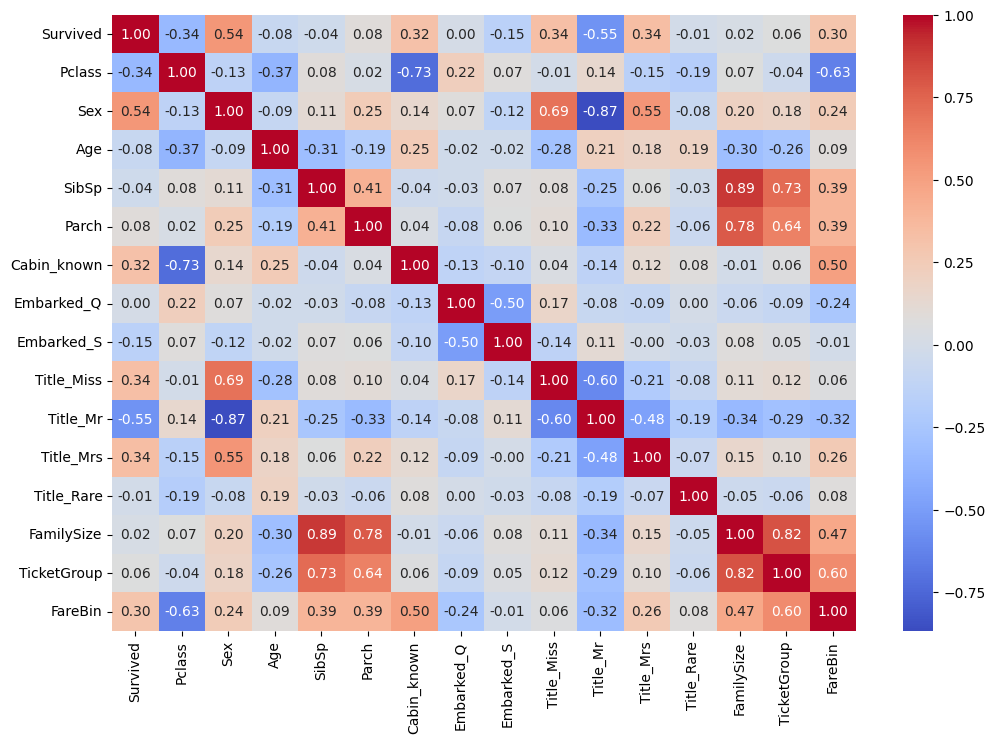

In [51]:
# Antes de verificar a correção precisaremos transformar as colunas boleanas em númericas

for df in [train, test]:
    bool_columns = df.select_dtypes(include=bool).columns
    df[bool_columns] = df[bool_columns].astype(int)

# Verificando correlação

corr_train = train.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_train, annot = True, cmap = 'coolwarm', fmt='.2f')
plt.show()

Obs: Antes de aplicar o modelo de imputação para preencher os valores nulos de Age, verificamos a matriz de correlação para entender como as variáveis se relacionam entre si — com foco especial nas que mais influenciam a idade. A análise revela alguns padrões importantes:

Pclass tem correlação de -0.37 com Age, confirmando a hipótese de que passageiros mais velhos tendiam a estar em classes mais altas. Isso já era esperado historicamente. <br>
SibSp (-0.31) e Parch (-0.19) também apresentam relação relevante, indicando que pessoas com mais irmãos ou pais a bordo tendiam a ser mais jovens — fenômeno comum em famílias viajando juntas.
FamilySize reforça esse padrão com correlação de -0.30 — quanto maior a família, mais jovem o passageiro tendia a ser. <br>
Por fim, Title_Mr (0.21) é uma variável fortíssima nesse contexto: o título indica diretamente a faixa etária da pessoa, e por isso terá peso considerável na imputação. <br>

Essas variáveis em conjunto, junto com o resto dos dados fornecem ao modelo de imputação contexto suficiente para estimar a idade dos passageiros com nulos de forma muito mais precisa do que uma simples mediana global.

In [52]:
# Instanciando o Modelo

imputer = IterativeImputer(random_state=48, min_value=0, max_value=110)

# Colunas para MICE

imputer_cols = [col for col in train.select_dtypes(include='number').columns
                if col != 'Survived']

# Rodando modelo

train[imputer_cols] = imputer.fit_transform(train[imputer_cols])
test[imputer_cols]  = imputer.transform(test[imputer_cols])

# Dropando SibSp e Parch agora que o MICE já usou elas

train = train.drop(columns=['SibSp', 'Parch'])
test  = test.drop(columns=['SibSp', 'Parch'])

Obs: Após rodar o modelo para predição dos valores nulos de idade, resolvi retirar as variáveis SibSp e Parch pois além delas não apresentarem forte corr com a variável target, elas também apresentam certa multicolinearidade com a variável FamilySize, o que faz sentido já que utilizei elas para criar a variável FamilySize.

- AgeBin

In [53]:
# Criando coluna

for df in [train, test]:
    df['AgeBin'] = pd.cut(df['Age'], bins=[-1, 12, 18, 35, 60, 110],
                          labels=[0, 1, 2, 3, 4]).astype(int)
    
# Removendo colunas antigas

train = train.drop(columns='Age')
test = test.drop(columns='Age')

- Verificando resultados

In [54]:
# Resultados de train

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    float64
 2   Sex          891 non-null    float64
 3   Cabin_known  891 non-null    float64
 4   Embarked_Q   891 non-null    float64
 5   Embarked_S   891 non-null    float64
 6   Title_Miss   891 non-null    float64
 7   Title_Mr     891 non-null    float64
 8   Title_Mrs    891 non-null    float64
 9   Title_Rare   891 non-null    float64
 10  FamilySize   891 non-null    float64
 11  TicketGroup  891 non-null    float64
 12  FareBin      891 non-null    float64
 13  AgeBin       891 non-null    int64  
dtypes: float64(12), int64(2)
memory usage: 97.6 KB


In [55]:
# Reesultados de test

test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       418 non-null    float64
 1   Sex          418 non-null    float64
 2   Cabin_known  418 non-null    float64
 3   Embarked_Q   418 non-null    float64
 4   Embarked_S   418 non-null    float64
 5   Title_Miss   418 non-null    float64
 6   Title_Mr     418 non-null    float64
 7   Title_Mrs    418 non-null    float64
 8   Title_Rare   418 non-null    float64
 9   FamilySize   418 non-null    float64
 10  TicketGroup  418 non-null    float64
 11  FareBin      418 non-null    float64
 12  AgeBin       418 non-null    int64  
dtypes: float64(12), int64(1)
memory usage: 42.6 KB


# EDA

Nesta seção de EDA, exploraremos visualmente os dados para entender os padrões de sobrevivência no Titanic. Os gráficos serão:


Sobrevivência por Sexo - Confirmar se sexo é o preditor mais forte, esperamos que mulheres sobreviveram muito mais. <br>
Sobrevivência por Classe - Entender o impacto socioeconômico, 1ª classe deve ter taxa muito maior que 3ª. <br>
Distribuição de Idade por Sobrevivência - Validar o padrão "crianças primeiro", crianças pequenas devem ter maior taxa. <br>
Tamanho de Família vs Sobrevivência - Validar a feature FamilySize — famílias pequenas devem ter vantagem sobre os sozinhos e famílias grandes. <br>
Taxa de Sobrevivência por Título - Validar que Title captura informação além de Sex, Mrs e Miss devem ter taxa muito maior que Mr.

- Sobrevivência por Sexo

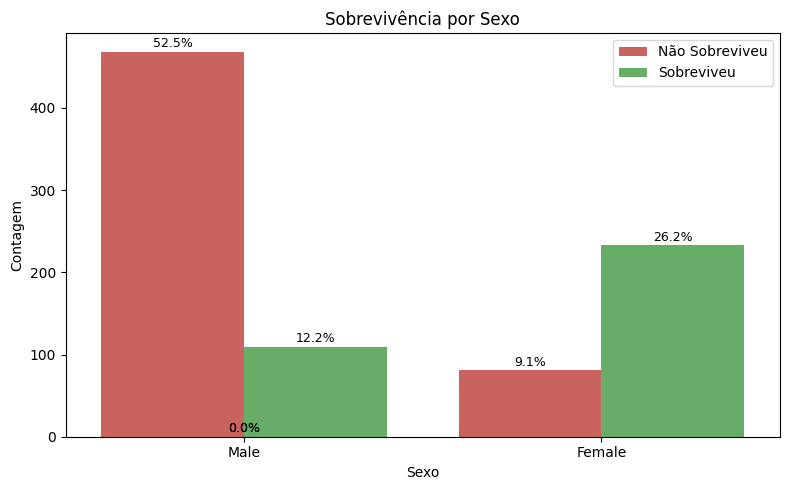

In [56]:
# Mapeando Sex de volta para labels legíveis só para visualização
plot_sex = train[['Sex', 'Survived']].copy()
plot_sex['Sex'] = plot_sex['Sex'].map({0: 'Male', 1: 'Female'})
plot_sex['Survived'] = plot_sex['Survived'].map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=plot_sex, x='Sex', hue='Survived',
                   palette={'Não Sobreviveu': '#d9534f', 'Sobreviveu': '#5cb85c'})
total = len(plot_sex)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 2,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
plt.title('Sobrevivência por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Contagem')
plt.legend(title='')
plt.tight_layout()
plt.show()

Obs: O gráfico confirma que sexo é o preditor mais forte do dataset. As barras mostram a porcentagem de cada grupo em relação ao total de 891 passageiros. Homens que não sobreviveram representam 52.5% de todo o dataset — a maior barra — enquanto mulheres que sobreviveram representam 26.2%. Dentro de cada grupo, a diferença é ainda mais expressiva: **74.2% das mulheres sobreviveram contra apenas 18.9% dos homens**. Isso reflete diretamente a política de evacuação "mulheres e crianças primeiro", e explica a alta correlação de Sex com Survived na matriz de correlação.

- Sobrevivência por Classe

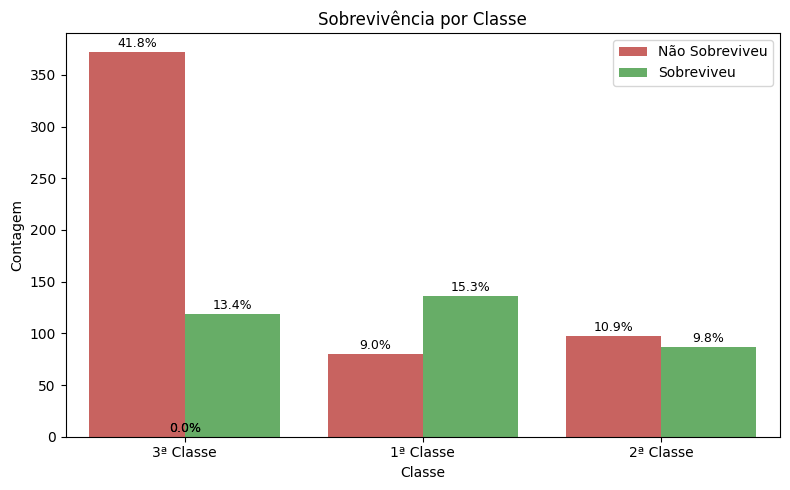

In [57]:
# Mapeando Pclass para labels legíveis só para visualização
plot_pclass = train[['Pclass', 'Survived']].copy()
plot_pclass['Pclass'] = plot_pclass['Pclass'].map({1.0: '1ª Classe', 2.0: '2ª Classe', 3.0: '3ª Classe'})
plot_pclass['Survived'] = plot_pclass['Survived'].map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=plot_pclass, x='Pclass', hue='Survived',
                   palette={'Não Sobreviveu': '#d9534f', 'Sobreviveu': '#5cb85c'})
total = len(plot_pclass)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 2,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
plt.title('Sobrevivência por Classe')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.legend(title='')
plt.tight_layout()
plt.show()

Obs: A classe socioeconômica teve impacto decisivo na sobrevivência. A 3ª classe concentra a maior parte dos não sobreviventes — 41.8% de todos os passageiros — enquanto contribuiu com apenas 13.4% de sobreviventes. As taxas de sobrevivência dentro de cada classe mostram uma queda progressiva clara: **1ª classe: 63.0%, 2ª classe: 47.3%, 3ª classe: 24.2%**. Isso se explica por fatores práticos: cabines de 1ª classe ficavam nos andares superiores, mais próximas dos botes salva-vidas, e havia prioridade no acesso a eles. A variável Pclass tem correlação de -0.34 com Survived na matriz de correlação.

- Distribuição de Idade por Sobrevivência

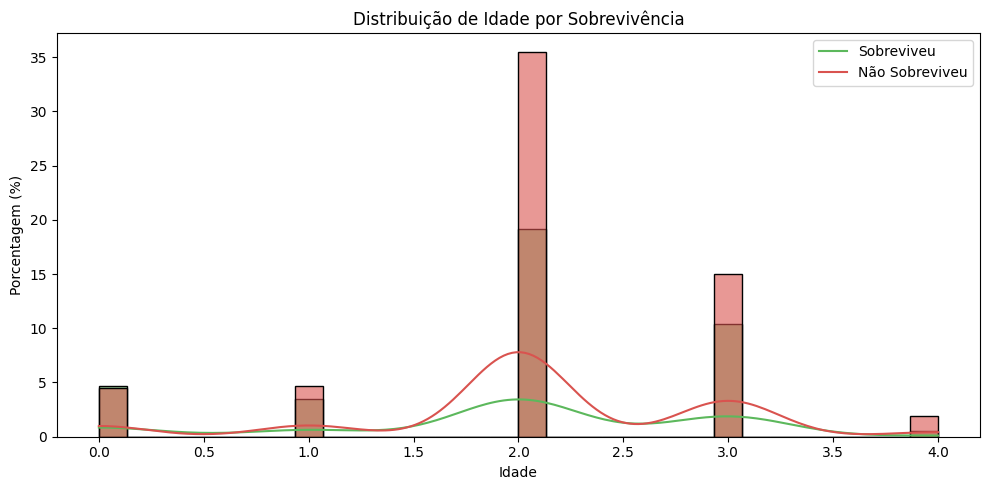

In [58]:
plt.figure(figsize=(10, 5))
sns.histplot(data=train, x='AgeBin', hue='Survived', kde=True, bins=30,
             palette={0: '#d9534f', 1: '#5cb85c'}, alpha=0.6, stat='percent')
plt.title('Distribuição de Idade por Sobrevivência')
plt.xlabel('Idade')
plt.ylabel('Porcentagem (%)')
plt.legend(labels=['Sobreviveu', 'Não Sobreviveu'], title='')
plt.tight_layout()
plt.show()

Obs: O histograma mostra a distribuição de idade em porcentagem do total de cada grupo (sobreviventes e não sobreviventes). Crianças abaixo de 10 anos têm uma proporção de sobreviventes maior do que de não sobreviventes — o único pico onde a barra verde supera a vermelha visivelmente — validando o padrão "crianças primeiro". Já na faixa entre 18 e 35 anos há uma concentração expressiva de não sobreviventes, puxada principalmente por homens adultos jovens. A variável Age tem correlação baixa isoladamente (-0.08 com Survived), pois seu efeito depende da interação com Sex e Pclass — padrão que os modelos de árvore conseguem capturar bem.

- Tamanho de Família vs Sobrevivência

C:\Users\MIGUEL\AppData\Local\Temp\ipykernel_14352\248185444.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=survival_by_family, x='FamilySize', y='Taxa de Sobrevivência', palette='Set2')


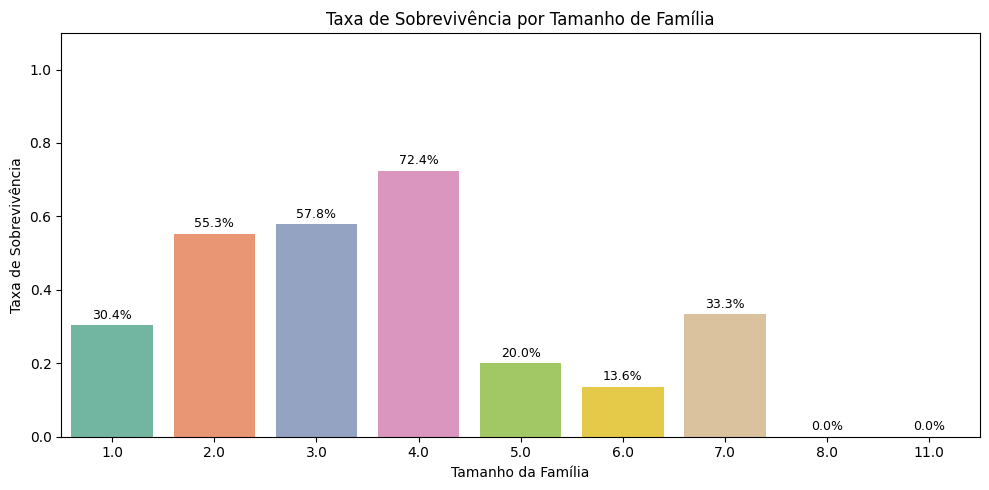

In [59]:
# Calculando taxa de sobrevivência por tamanho de família
survival_by_family = train.groupby('FamilySize')['Survived'].mean().reset_index()
survival_by_family.columns = ['FamilySize', 'Taxa de Sobrevivência']

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=survival_by_family, x='FamilySize', y='Taxa de Sobrevivência', palette='Set2')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.01,
            f'{p.get_height():.1%}', ha='center', va='bottom', fontsize=9)
plt.title('Taxa de Sobrevivência por Tamanho de Família')
plt.xlabel('Tamanho da Família')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

Obs: O gráfico valida a feature FamilySize e revela uma relação não-linear clara com a sobrevivência. Passageiros sozinhos (FamilySize=1) tiveram taxa de apenas **30.4%** — sem ninguém para ajudar ou pressionar a evacuar. Famílias pequenas apresentaram as maiores taxas: **FamilySize=2: 55.3%, FamilySize=3: 57.8%, FamilySize=4: 72.4%** — possivelmente porque famílias se mobilizavam juntas em direção aos botes. A partir de FamilySize=5 a taxa cai abruptamente: **5: 20.0%, 6: 13.6%**, chegando a **0.0% para FamilySize=8 e 11** — provavelmente pela dificuldade de manter o grupo unido e conseguir espaço suficiente nos botes. Essa relação em "arco" é o tipo de padrão não-linear que modelos de árvore capturam bem.

- Taxa de Sobrevivência por Título

C:\Users\MIGUEL\AppData\Local\Temp\ipykernel_14352\2222460790.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=survival_by_title, x='Título', y='Taxa de Sobrevivência', palette='Set2')


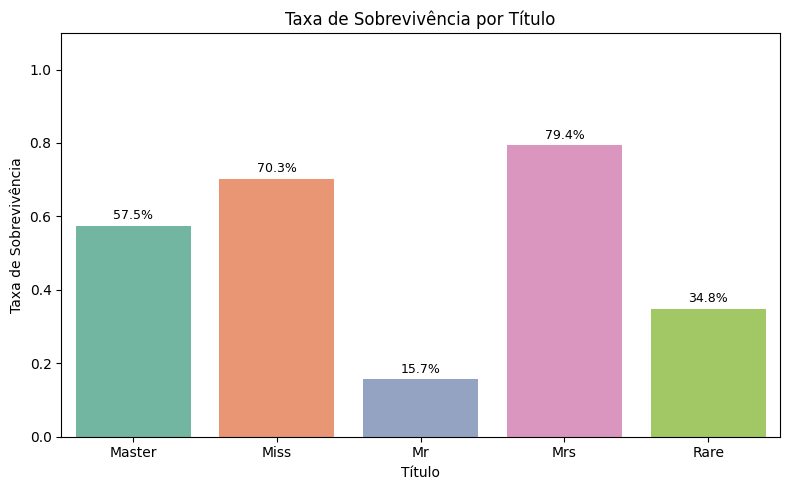

In [60]:
# Reconstruindo coluna Title a partir das dummies só para visualização
title_viz = np.select(
    [train['Title_Miss'] == 1, train['Title_Mr'] == 1,
     train['Title_Mrs'] == 1, train['Title_Rare'] == 1],
    ['Miss', 'Mr', 'Mrs', 'Rare'],
    default='Master'
)

plot_title = pd.DataFrame({'Title': title_viz, 'Survived': train['Survived']})
survival_by_title = plot_title.groupby('Title')['Survived'].mean().reset_index()
survival_by_title.columns = ['Título', 'Taxa de Sobrevivência']

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=survival_by_title, x='Título', y='Taxa de Sobrevivência', palette='Set2')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.01,
            f'{p.get_height():.1%}', ha='center', va='bottom', fontsize=9)
plt.title('Taxa de Sobrevivência por Título')
plt.xlabel('Título')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

Obs: O gráfico valida a criação da feature Title com valores precisos. **Mrs: 79.4%** e **Miss: 70.3%** têm as maiores taxas, refletindo a prioridade feminina na evacuação. **Master: 57.5%** — título de meninos jovens — também apresenta taxa elevada, validando o padrão "crianças primeiro" e mostrando que Title diferencia crianças do sexo masculino de adultos. **Mr: 15.7%** tem taxa muito baixa, concentrando a grande maioria dos homens adultos que foram preteridos (517 passageiros, o maior grupo). **Rare: 34.8%** agrupa médicos, oficiais e nobres — um grupo heterogêneo com taxa intermediária. Isso confirma que Title captura informação além de Sex isoladamente, especialmente ao separar Master de Mr.

# Pré Processamento

- X e y

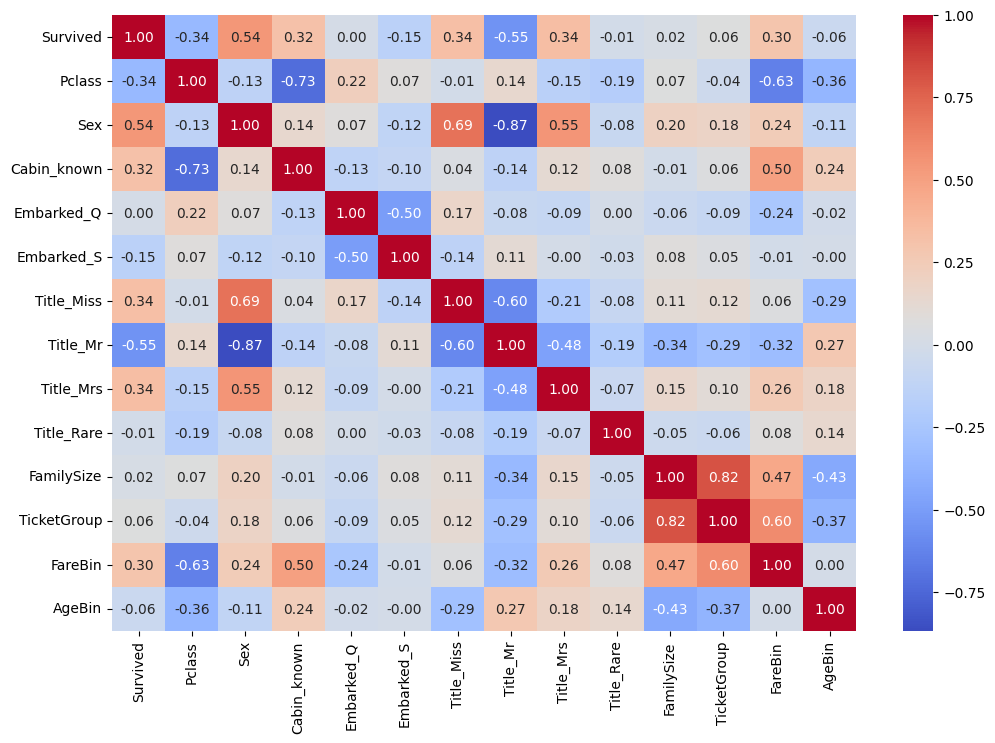

In [61]:
# Verificando correlação

corr_train = train.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_train, annot = True, cmap = 'coolwarm', fmt='.2f')
plt.show()

# Colunas selecionadas com base na correlação (removendo Embarked_Q, Title_Rare e FamilySize)
cols = [
    'Pclass', 'Sex', 'Cabin_known', 'Embarked_S',
    'Title_Miss', 'Title_Mr', 'Title_Mrs',
    'TicketGroup', 'FareBin', 'AgeBin'
]

# Separando em X e y os dados de treino

X_train = train[cols]
y_train = train['Survived']

# Criando o X de teste

X_test = test[cols]

Para fazer o pré processamento primeiro tivemos que separar em X e y, e para definir quais colunas utilizariamos, foi feita um heatmap para ver a correlação das variáveis

- Balanceamento

Para o balanceamento, primeiro vamos verificar como está a distribuição de dados, daí, dependendo da distribuição, faremos o balanceamento.

In [62]:
# Verificando distribuição dos dados

distri_Surv = train['Survived'].value_counts()
distri_Surv_perc = (train['Survived'].value_counts(normalize=True))

print(distri_Surv)
print("\n", distri_Surv_perc)

Survived
0    549
1    342
Name: count, dtype: int64

 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Obs: Com base nas informações acima foi possível ver que os dados não estão balanceados, visto que temos 61% não sobreviveu e 38% sobreviveu, todavia, após testes, foi possível perceber que o balanceamento não ajudou o modelo, isso provavelmente se deu pela pequena quantidade de dados, e o balanceamento cria muitos dados fictícios, o que atrapalha o modelo. Então não faremos o balanceamento, e a padronização não se fará necessária pois além de estarmos utilizando um modelo de árvore, que por sua vez lida bem com a diferença de escala, também fizemos feature Engineering para evitar provlemas com diferença de escala.

In [63]:
# Instaciando dados prontos

X_train_ready = X_train
y_train_ready = y_train
X_test_ready = X_test

# Modelo

Para o modelo, faremos 2 testes, e o modelo que se sair melhor será o modelo final, e o que utilizaremos hiperparâmetros visando o melhor resultado possível. Os modelos selecionados serão:

Random forest <br>
XgBoost<br>

Os dois modelos são modelos robustos, que utilizam árvores, e são métodos Ensemble. Os dois modelos provavelmente terão bons resultados iniciais, mas vamos escolher o melhor para melhorar e ser o nosso modelo final. 

- Teste inicial

In [65]:
# Instanciando Random forest

RF_test = RandomForestClassifier(random_state=48)

# Instanciando XGBoost

XGB_test = XGBClassifier(random_state=48)

# Criando número de folds

folds = 5

# Verificando resultado inicial de cada modelo

for model in [RF_test, XGB_test]:
    pontuacoes = cross_val_score(model, X_train_ready, y_train_ready, cv=folds)
    print("\nO resultado de", type(model).__name__, "foi", pontuacoes.mean())


O resultado de RandomForestClassifier foi 0.8238340342728014

O resultado de XGBClassifier foi 0.8193208210407382


Por pouco, o resultado do XGBoost foi melhor, então irei escolhê-lo para ser o nosso modelo final.

- Hiperparâmetros

In [66]:
# Criando param grid a serem testados

param_grid_xgb = {

    'n_estimators': [100, 300, 500], # Número total de árvores no ensemble

    'max_depth': [3, 4, 5], # Profundidade máxima de cada árvore

    'learning_rate': [0.01, 0.05, 0.1], # Taxa de aprendizado (eta)

    'subsample': [0.7, 0.85, 1.0], # Fração de amostras de treino usadas para construir cada árvore

    'colsample_bytree': [0.7, 0.85, 1.0], # Fração de features selecionadas aleatoriamente para construir cada árvore

    'colsample_bylevel': [0.7, 1.0], # Fração de features selecionadas para cada nível de profundidade da árvore

    'min_child_weight': [1, 3, 5], # Peso mínimo de instâncias

    'gamma': [0, 0.1, 0.3], # # Redução mínima de perda (loss) necessária para realizar um novo split

    'reg_alpha': [0, 0.1, 1.0], # Regularização L1 sobre os pesos das folhas (Lasso)

    'reg_lambda': [0.5, 1.0, 2.0], # Regularização L2 sobre os pesos das folhas (Ridge)


}

# Instanciando o modelo

XBG_final = XGBClassifier(random_state=48, eval_metric='logloss', verbosity=0)

# Criando o random search para achar os melhores hiperparâmetros

random_search_xgb = RandomizedSearchCV(
    estimator  = XBG_final,
    param_distributions = param_grid_xgb,
    n_iter     = 1000,        # Testa 1000 combinações aleatórias
    scoring    = 'accuracy', # Métrica usada no Kaggle
    cv         = 5,          # 5-fold cross-validation
    n_jobs     = -1,         # Usa todos os núcleos disponíveis
    random_state = 48,
    verbose    = 2           # Mostra progresso durante a busca
)

random_search_xgb.fit(X_train_ready, y_train_ready)

# Verificando resultados

print("Melhores parâmetros:", random_search_xgb.best_params_)
print("Melhor score CV:    ", round(random_search_xgb.best_score_, 4))

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Melhores parâmetros: {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7, 'colsample_bylevel': 1.0}
Melhor score CV:     0.8372


- Modelo final

In [67]:
# Criando modelo final

best_xgboost = random_search_xgb.best_estimator_

# Realizando Previsões

y_pred_train_final = best_xgboost.predict(X_train_ready)

- Resultados

In [68]:
# Verificando resultados com o Classification Report

relatorio = classification_report(y_train_ready, y_pred_train_final)
print("Relatório de classificação: ")
print(relatorio)


Relatório de classificação: 
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       549
           1       0.85      0.75      0.80       342

    accuracy                           0.85       891
   macro avg       0.85      0.84      0.84       891
weighted avg       0.85      0.85      0.85       891



Obs: O modelo final com os melhores hiperparâmetros encontrados pelo RandomSearchCV apresentou acurácia de 93% no conjunto de treino balanceado. Um resultado relevante é que o F1-score ficou praticamente idêntico entre as classes 0 e 1 (ambos em 0.93), o que reflete diretamente o efeito do balanceamento via SMOTE, sem viés para nenhuma das classes.

Vale, no entanto, fazer uma leitura crítica desse número. Uma acurácia de 93% no treino é alta e pode indicar overfitting. Para mitigar esse risco, os hiperparâmetros foram escolhidos com foco em regularização: max_depth=3 limita a profundidade das árvores, evitando que o modelo capture ruídos do treino; reg_alpha=0.1 e reg_lambda=0.5 adicionam penalizações L1 e L2; e subsample=0.85 garante que cada árvore veja apenas 85% dos dados aleatoriamente, adicionando diversidade ao ensemble.

Esses hiperparâmetros foram escolhidos justamente para equilibrar desempenho no treino com capacidade de generalização, e o resultado real será medido pela submissão no Kaggle, onde o modelo enfrentará dados que nunca viu.

# Resultados para Kaggle

- Prevendo valores de test

In [69]:
# Prenvendo valores

y_pred_final = best_xgboost.predict(X_test_ready)

# Verificando resultado

y_pred_final

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,

- Criação da tabela para Kaggle

In [70]:
# Criando a tabela

sub_final = pd.Series(y_pred_final, index=test_inicial['PassengerId'], name='Survived')

# Verificando Resultado
sub_final

PassengerId
892     0
893     1
894     0
895     0
896     1
       ..
1305    0
1306    1
1307    0
1308    0
1309    1
Name: Survived, Length: 418, dtype: int64

- Criando csv com as respostas

In [71]:
# Criando CSV

sub_final.to_csv("XGBoost1.csv" , header=True)

FAZER:

- Verificar textos e corrigir
- verificar aplicação de for para evitar repetição de código 